We we'll try to modelize the market making simulation of Avellaneda-Stoikov model

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [126]:
# Comportement du prix : mouvement brownien arithmétique (Avellaneda-Stoikov),
# et non géométrique

def simulate_bm(T, n, n_paths,s,sigma):
    dt = T / n  # pas de temps : [0,T] découpé en n intervalles

    dW = sigma * np.sqrt(dt) * np.random.randn(n_paths, n)  # accroissements indépendants ~ N(0, sigma^2 * dt)

    W = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(dW, axis=1)], axis=1)  # cumsum reconstruit la trajectoire : W_tk = somme des dW_j (télescopage)

    W= W + s #départ de l'actif en s
    return W

In [141]:
def simulate_bm_plot(T, n, n_paths,s,sigma):
    W=simulate_bm(T, n, n_paths,s,sigma)

    t = np.linspace(0, T, n + 1) #barre de temps
    for k in range(0,n_paths):
        plt.plot(t,W[k])
    plt.xlabel('t')
    plt.ylabel('Wt')
    plt.title('Brownian Motion')
    plt.show()


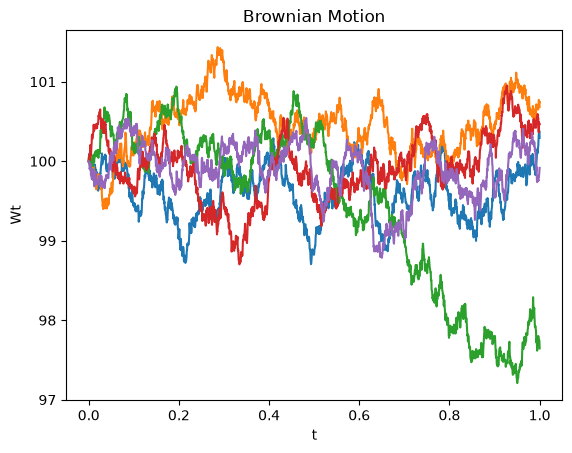

In [146]:
simulate_bm_plot(1, 2000, n_paths=5,s=100,sigma=2)

In [181]:
T=1
sigma=2
dt=0.005
q=0
gamma=0.1
k=1.5
A=140

In [ ]:
#Let's try to calculate the benchmark strategy ? 

def simule_PNL_benchmark(T,dt,sigma,q,gamma,k,A,s):
    
    n=int(T/dt)
    t=np.linspace(0,T,n+1)

    w=0 #initialisation de la wealth
    
    
    wealth=[0]*(n+1) #tableau de suivi de la wealth
    p_a=[0]*(n+1) #tableau de suivi des prix ask
    p_b=[0]*(n+1) #tableau de suivi des prix bid

    spread=gamma*(sigma**2)*(T-t)+(2/gamma)*np.log(1+(gamma/k)) # δa + δb 

    mid_price=simulate_bm(T, n, 1,s,sigma)[0]


    for i in range(n+1):

        delta_a= (spread[i]/2) #strategy benchmark : symetric !
        delta_b= (spread[i]/2)

        lambda_a_delta_a=A*np.exp(-k*delta_a) # λ(δa) : our arrival rate is a function of δa (completely normal considering that price affect sales)
        lambda_b_delta_b=A*np.exp(-k*delta_b) # λ(δb) 

        a=np.random.binomial(1,1-np.exp(-lambda_a_delta_a*dt)) #we use 1-exp(-λ(δa)) rather than λ(δa) (which could be >1)
        b=np.random.binomial(1,1-np.exp(-lambda_b_delta_b*dt))

        q= q+b-a # increase by 1 with probability λ(δa)*dt and decrease by 1 with probability λ(δb)*dt

        w = w + (s+delta_a)*a - (s-delta_b)*b
        
        #=== To follow the evolutions
        wealth[i]=w

        p_a[i]=mid_price[i]+delta_a
        p_b[i]=mid_price[i]-delta_b
    

    
    return wealth,p_a,p_b,mid_price,q


    

In [ ]:
def simule_PNL_benchmark_plot(T,dt,sigma,q,gamma,k,A,s):
    n=int(T/dt)
    t=np.linspace(0,T,n+1)
    wealth,p_a,p_b,mid_price,q=simule_PNL_benchmark(T,dt,sigma,q,gamma,k,A,s)

    plt.plot(t,mid_price,color='black',label='Mid-market price')
    plt.scatter(t,p_a,facecolors='red', s=15,label='Price asked')
    plt.scatter(t,p_b,facecolors='none',edgecolors='red',s=20, label='Price bid')
    plt.xlabel("t")
    plt.legend()
    plt.show()

    plt.plot(t,wealth,color='orange',label='wealth')
    plt.xlabel("t")
    plt.title("Wealth evolution")
    plt.legend()
    plt.show()

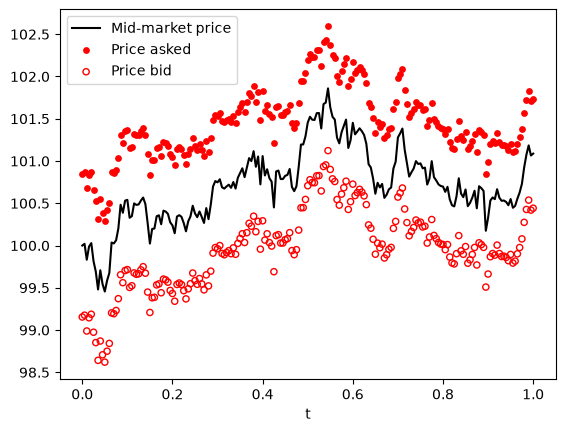

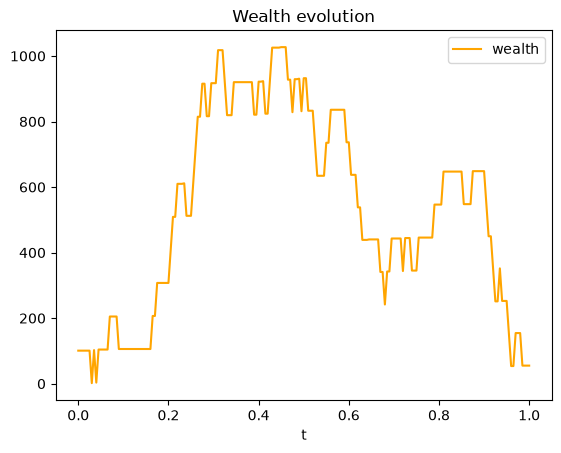

In [227]:
simule_PNL_benchmark_plot(T,dt,sigma,q,gamma,k,A,s)

In [ ]:
#Now let's simulate it's strategy 

def simule_PNL_AS(T,dt,sigma,q,gamma,k,A,s):
    
    n=int(T/dt)
    t=np.linspace(0,T,n+1)

    w=0 #initialisation de la wealth
    
    
    wealth=[0]*(n+1) #tableau de suivi de la wealth
    p_a=[0]*(n+1) #tableau de suivi des prix ask
    p_b=[0]*(n+1) #tableau de suivi des prix bid
    res_price_evo=[0]*(n+1) #tableau de suivi du prix de réservation

    spread=gamma*(sigma**2)*(T-t)+(2/gamma)*np.log(1+(gamma/k)) # δa + δb 

    mid_price=simulate_bm(T, n, 1,s,sigma)[0]


    for i in range(n+1):

        reserve_price=mid_price[i]-q*gamma*(sigma**2)*(T-t[i]) #valorisation de l'actif selon l'agent à la période k

        delta_a= (spread[i]/2) - q*gamma*(sigma**2)*(T-t[i]) # -q*gamma*(sigma**2)*(T-t) = reserve_price - mid_price
        delta_b= (spread[i]/2) + q*gamma*(sigma**2)*(T-t[i]) # +q*gamma*(sigma**2)*(T-t) = mid_price - reserve_price

        lambda_a_delta_a=A*np.exp(-k*delta_a) # λ(δa) : our arrival rate is a function of δa (completely normal considering that price affect sales)
        lambda_b_delta_b=A*np.exp(-k*delta_b) # λ(δb) 

        a=np.random.binomial(1,1-np.exp(-lambda_a_delta_a*dt)) #we use 1-exp(-λ(δa)) rather than λ(δa) (which could be >1)
        b=np.random.binomial(1,1-np.exp(-lambda_b_delta_b*dt))

        q= q+b-a # increase by 1 with probability λ(δa)*dt and decrease by 1 with probability λ(δb)*dt

        w = w + (s+delta_a)*a - (s-delta_b)*b
        
        #=== To follow the evolutions
        wealth[i]=w

        p_a[i]=mid_price[i]+delta_a
        p_b[i]=mid_price[i]-delta_b

        res_price_evo[i]=reserve_price
    

    
    return wealth,p_a,p_b,mid_price,res_price_evo,q


In [ ]:
def simule_PNL_AS_plot(T,dt,sigma,q,gamma,k,A,s):
    n=int(T/dt)
    t=np.linspace(0,T,n+1)
    wealth,p_a,p_b,mid_price,res_price_evo,q = simule_PNL_AS(T,dt,sigma,q,gamma,k,A,s)

    plt.plot(t,mid_price,color='black',label='Mid-market price')
    plt.plot(t,res_price_evo,color='green',label='Indifference price')
    plt.scatter(t,p_a,facecolors='red', s=15,label='Price asked')
    plt.scatter(t,p_b,facecolors='none',edgecolors='red',s=20, label='Price bid')
    plt.xlabel("t")
    plt.legend()
    plt.show()

    plt.plot(t,wealth,color='orange',label='wealth')
    plt.xlabel("t")
    plt.title("Wealth evolution")
    plt.legend()
    plt.show()

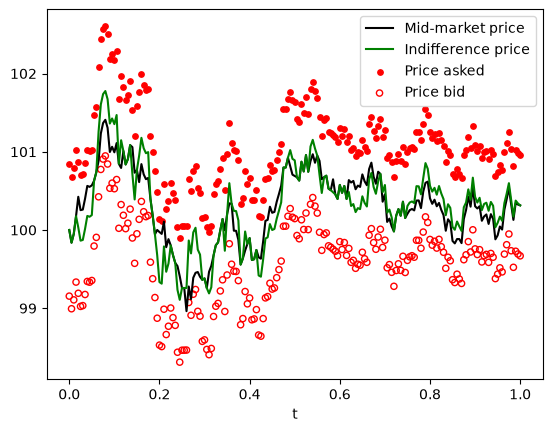

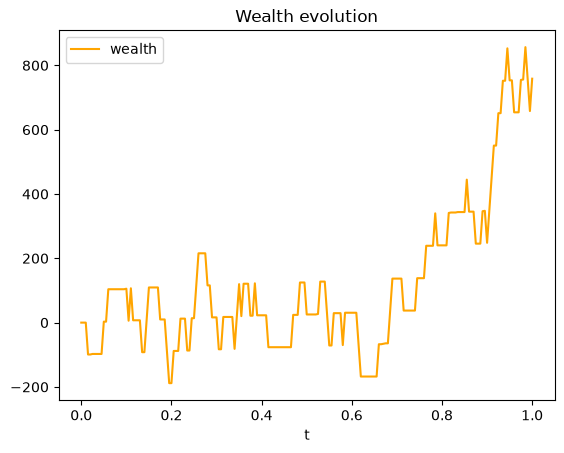

In [231]:
simule_PNL_AS_plot(T,dt,sigma,q,gamma,k,A,s)

In [ ]:
def simulation_comparison(nb_simulations):

    profit_bench_total=[0]*nb_simulations
    profit_AS_total=[0]*nb_simulations

    profit_bench=0 #init
    profit_AS=0

    q_bench_total=[0]*nb_simulations
    q_AS_total=[0]*nb_simulations

    for i in range(nb_simulations):
        wealth_bench,_,_,mid_price_bench,q_bench=simule_PNL_benchmark(T,dt,sigma,q,gamma,k,A,s)
        wealth_AS,_,_,mid_price_AS,_,q_AS=simule_PNL_AS(T,dt,sigma,q,gamma,k,A,s)

        profit_bench=wealth_bench[-1]+mid_price_bench[-1]*q_bench #profit = wealth + inventaire * mid_price
        profit_AS=wealth_AS[-1]+mid_price_AS[-1]*q_AS
        
        profit_bench_total[i]=profit_bench
        profit_AS_total[i]=profit_AS

        q_bench_total[i]=q_bench
        q_AS_total[i]=q_AS



    print("Symetric :")
    print("="*40)
    print(f"Profit has a mean of {np.mean(profit_bench_total)} and a std of {np.std(profit_bench_total, ddof=1)}")
    print(f"Final q has a mean of {np.mean(q_bench_total)} and a std of {np.std(q_bench_total, ddof=1)}")

    print()
    print("Inventory Strategy :")
    print("="*40)
    print(f"Profit has a mean of {np.mean(profit_AS_total)} and a std of {np.std(profit_AS_total, ddof=1)}")
    print(f"Final q has a mean of {np.mean(q_AS_total)} and a std of {np.std(q_AS_total, ddof=1)}")

